In [1]:
import pandas as pd
import os
import glob

In [4]:
sdrf = pd.read_csv(r"/Users/saurabhlevin/Deployment/flood-data-ecosystem-Assam/Sources/SDRF/data/sec_meeting/processed/line_items.csv")

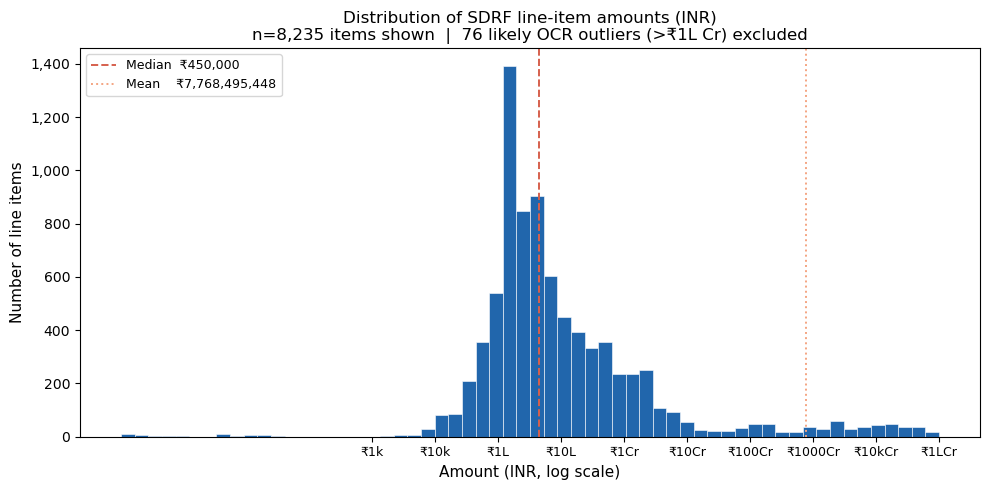

Statistic                           Value
------------------------------------------
Count (valid)                       8,235
Nulls                                  31
OCR outliers                           76
Min                                    ₹0
Median                           ₹450,000
Mean                       ₹7,768,495,448
95th pct                   ₹2,569,279,527
Max (clean)            ₹1,000,000,000,000


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

line_items = pd.read_csv(
    r"/Users/saurabhlevin/Deployment/flood-data-ecosystem-Assam/Sources/SDRF/data/sec_meeting/processed/line_items.csv"
)

amounts = line_items["amount_inr"].dropna()
amounts = amounts[amounts > 0]

# Amounts span ~12 orders of magnitude; log10 scale gives a readable distribution.
# Values above 1e12 (>10,000 crore) are almost certainly OCR parse errors.
OUTLIER_THRESHOLD = 1e12
clean   = amounts[amounts <= OUTLIER_THRESHOLD]
outlier = amounts[amounts >  OUTLIER_THRESHOLD]

log_vals = np.log10(clean)

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(log_vals, bins=60, color="#2166ac", edgecolor="white", linewidth=0.4)

# Label x-axis with rupee values instead of log exponents
rupee_ticks = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
rupee_labels = ["₹1k", "₹10k", "₹1L", "₹10L", "₹1Cr", "₹10Cr",
                "₹100Cr", "₹1000Cr", "₹10kCr", "₹1LCr"]
ax.set_xticks(rupee_ticks)
ax.set_xticklabels(rupee_labels, fontsize=9)

ax.axvline(np.log10(clean.median()), color="#d6604d", linestyle="--",
           linewidth=1.4, label=f"Median  ₹{clean.median():,.0f}")
ax.axvline(np.log10(clean.mean()),   color="#f4a582", linestyle=":",
           linewidth=1.4, label=f"Mean    ₹{clean.mean():,.0f}")

ax.set_xlabel("Amount (INR, log scale)", fontsize=11)
ax.set_ylabel("Number of line items", fontsize=11)
ax.set_title(
    f"Distribution of SDRF line-item amounts (INR)\n"
    f"n={len(clean):,} items shown  |  {len(outlier)} likely OCR outliers (>₹1L Cr) excluded",
    fontsize=12
)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.show()

print(f"{'Statistic':<20} {'Value':>20}")
print("-" * 42)
for label, val in [
    ("Count (valid)",    f"{len(clean):,}"),
    ("Nulls",            f"{line_items['amount_inr'].isna().sum():,}"),
    ("OCR outliers",     f"{len(outlier):,}"),
    ("Min",              f"₹{clean.min():,.0f}"),
    ("Median",           f"₹{clean.median():,.0f}"),
    ("Mean",             f"₹{clean.mean():,.0f}"),
    ("95th pct",         f"₹{clean.quantile(0.95):,.0f}"),
    ("Max (clean)",      f"₹{clean.max():,.0f}"),
]:
    print(f"{label:<20} {val:>20}")

Summary: amount_inr Parsing Issues in Cache
154 unique affected items across 21 meetings. Three distinct root causes:

Category A — Double Unit Suffix (16 items, values inflated ×100)
The raw string explicitly contains "Cr." or "lakh" and the page default_amount_unit was also applied on top, squaring the multiplier.

Meeting	Raw	Default Unit	Stored (wrong)	Correct
42nd / 0003	"178.79 Cr."	crore	₹178,790,000,000	₹1,787,900,000
51st / 0004	"Rs. 140.20 Cr."	crore	₹140,200,000,000	₹1,402,000,000
51st / 0004	"Rs. 411.12 Cr."	crore	₹411,120,000,000	₹4,111,200,000
54th / 0006	"Rs. 313.69 Cr."	crore	₹313,690,000,000	₹3,136,900,000
39th / 0016	"Rs. 6.00 Cr."	lakh	₹6,000,000,000	₹60,000,000
40th / 0002	"Rs. 5.00 Cr."	lakh	₹5,000,000,000	₹50,000,000
Fix: When raw contains an explicit unit suffix, use only that suffix and ignore default_amount_unit.

Category B — Indian-Format Rupees Multiplied by Unit (138 items, values inflated ×10⁵ to ×10⁷)
Raw values use Indian comma notation (e.g., 17,00,000 = ₹17 lakh, 8,49,25,790 = ₹8.49 crore). The parser stripped commas and treated the result as a "lakh" or "crore" count, then multiplied — producing astronomically wrong values.

Sub-case B1: inflated (stored ×100,000 or ×10,000,000 too large)

Meeting	Raw	Unit	Stored	Correct
41st / 0001	"17,00,000"	lakh	₹170,000,000,000	₹1,700,000
41st / 0097	"49,27,13,595"	lakh	₹49,271,359,500,000	₹492,713,595
49th / 0002	"8,49,25,790"	crore	₹849,257,900,000,000	₹84,925,790
44th / 0002	"1,33,36,502"	crore	₹133,365,020,000,000	₹13,336,502
51st / 0006	"1,11,98,100/-"	crore	₹111,981,000,000,000	₹11,198,100
10th / 0023	"50,00,000"	lakh	₹500,000,000,000	₹5,000,000
...and ~130 more				
Sub-case B2: stored too small (~35 items with /- suffix)

These Indian-format amounts with /- were read as a fraction of a lakh. The parser appears to have interpreted the first two comma-groups as X.Y rather than as Indian digits:

Meeting	Raw	Stored (wrong)	Correct
42nd / 0048	"Rs.7,15,000/-"	₹71,500	₹715,000
42nd / 0048	"Rs.10,50,000/-"	₹10,500	₹1,050,000
42nd / 0048	"Rs.15,79,500/-"	₹15,795	₹1,579,500
41st / 0003	"Rs. 4,24,65,000"	₹42,465	₹42,465,000
55th / 0003	"Rs.1,31,87,680/-"	₹13,188	₹13,187,680
39th / 0016	"Rs. 12,45,000/-"	₹12,450	₹1,245,000
Category C — Source Data Issue (39th meeting, page 0002)
Raw values like "470695.48", "11064726.00", "2719200.00" with default_unit=lakh. If the PDF table header says "Rs. in Lakh", then these ARE lakh values (correct). But the resulting amounts (e.g., 470,695 lakh = ₹4,707 crore for a single crop category) seem implausibly large for 2019 Assam SDRF agricultural assistance. This needs source PDF verification — either the raw values are correctly in lakh (the stored amount_inr is right), or the table header was "Rs." not "Rs. in Lakh" and the values are already rupees.

Also notable: 47th meeting unit=rupees
"Rs. 61,02,060/-" with unit=rupees is stored as amount_inr=₹0.61 — the Indian-format parsing with /-  suffix applied in a rupees-unit context divided down to near-zero. Correct value: ₹6,102,060.

Scale in line_items.csv:

239 rows with amount_inr > ₹1,000 crore (almost all wrong)
76 rows with amount_inr > ₹10,000 crore (certainly wrong)
55 rows with amount_inr < ₹1,000 (likely too small)
The fix needs to be applied in the extraction script (02_extract_data.py) — the amount_inr and amount_lakh computation must: (1) detect Indian-comma format and treat it as rupees directly, (2) not apply default_amount_unit when the raw string already has a unit suffix.

## `amount_inr` Parsing Audit

Scans every cache JSON to detect three classes of incorrect `amount_inr` values produced by the extraction pipeline:

| Category | Root cause | Typical error |
|---|---|---|
| **A** | Raw string has a unit suffix *and* `default_amount_unit` also applied | ×100 too large |
| **B (large)** | Indian-comma rupee format (e.g. `17,00,000`) multiplied by page unit | ×10⁵ – ×10⁷ too large |
| **B (small)** | Indian-comma amount with `/-` suffix parsed as fractional lakh | 10–100× too small |

Run all cells below to regenerate the full issue list.

In [ ]:
import json, os, re
from pathlib import Path
from collections import defaultdict

CACHE_DIR = Path("/Users/saurabhlevin/Deployment/flood-data-ecosystem-Assam/Sources/SDRF/data/sec_meeting/processed/cache")

CRORE = 10_000_000
LAKH  = 100_000

def _strip_currency(s: str) -> str:
    return re.sub(r"(?i)rs\.?|/-|\s", "", s).strip()

def _unit_suffix(s: str):
    """Return 'crore' or 'lakh' if the raw string contains an explicit unit, else None."""
    m = re.search(r"(?i)\b(crore|cr\.?|lakh|lac)\b", s)
    if not m:
        return None
    tok = m.group(1).lower().rstrip(".")
    return "crore" if tok in ("crore", "cr") else "lakh"

def _is_indian_comma(s: str):
    """
    Return (True, rupee_value) if the string is Indian-notation rupees
    (groups of 2 digits after the leading group, final group of 3).
    e.g. 17,00,000 / 8,49,25,790 / 49,27,13,595
    """
    clean = _strip_currency(s)
    clean = re.sub(r"(?i)(crore|cr\.?|lakh|lac)$", "", clean).strip()
    if re.fullmatch(r"\d{1,2}(,\d{2})*,\d{3}", clean):
        return True, float(clean.replace(",", ""))
    return False, None

def scan_cache(cache_dir: Path) -> list[dict]:
    """
    Walk every meeting/page JSON in cache_dir.
    Return a deduplicated list of issue dicts, one per (meeting, page, raw) triple.
    """
    seen = set()
    issues = []

    for meeting in sorted(cache_dir.iterdir()):
        if not meeting.is_dir():
            continue
        for page_file in sorted(meeting.iterdir()):
            if page_file.suffix != ".json":
                continue
            data = json.loads(page_file.read_text())
            page_unit = data.get("default_amount_unit")  # lakh / crore / rupees / None

            for item in data.get("line_items", []):
                raw = str(item.get("amount_raw", ""))
                amt = item.get("amount_inr")
                if amt is None:
                    continue

                key = (meeting.name, page_file.name, raw)
                if key in seen:
                    continue
                seen.add(key)

                work = (item.get("work_text") or "")[:80]
                suffix = _unit_suffix(raw)

                # ── Category A: embedded unit suffix AND page unit both applied ──
                if suffix and page_unit in ("lakh", "crore"):
                    clean = re.sub(r"(?i)rs\.?|/-|crore|cr\.?|lakh|lac|\s", "", raw).strip()
                    try:
                        val = float(clean.replace(",", ""))
                    except ValueError:
                        continue
                    mult = CRORE if suffix == "crore" else LAKH
                    correct = val * mult
                    if correct > 0 and abs(correct - amt) / max(abs(amt), 1) > 0.01:
                        issues.append(dict(
                            category="A – double unit suffix",
                            meeting=meeting.name, page=page_file.name,
                            default_unit=page_unit, raw=raw,
                            stored_inr=amt, correct_inr=correct,
                            error_factor=amt / correct,
                            work=work,
                        ))
                    continue

                # ── Category B: Indian-comma rupee value multiplied by page unit ──
                is_indian, rupee_val = _is_indian_comma(raw)
                if is_indian and page_unit in ("lakh", "crore") and rupee_val:
                    mult = LAKH if page_unit == "lakh" else CRORE
                    category = (
                        "B-large (Indian format × unit)"
                        if amt > rupee_val
                        else "B-small (Indian format ÷ unit)"
                    )
                    issues.append(dict(
                        category=category,
                        meeting=meeting.name, page=page_file.name,
                        default_unit=page_unit, raw=raw,
                        stored_inr=amt, correct_inr=rupee_val,
                        error_factor=amt / rupee_val,
                        work=work,
                    ))

    return issues


issues = scan_cache(CACHE_DIR)
print(f"Total unique issues: {len(issues)}")
for cat, grp in sorted(defaultdict(list, 
    {k: [i for i in issues if i['category'] == k] for k in {i['category'] for i in issues}}
).items()):
    print(f"  {cat}: {len(grp)}")

In [ ]:
import pandas as pd

df = pd.DataFrame(issues)

def _fmt_inr(v):
    if v >= 1e7:
        return f"₹{v/1e7:.2f} Cr"
    if v >= 1e5:
        return f"₹{v/1e5:.2f} L"
    return f"₹{v:,.0f}"

df["stored"] = df["stored_inr"].apply(_fmt_inr)
df["correct"] = df["correct_inr"].apply(_fmt_inr)
df["error_×"] = df["error_factor"].apply(lambda x: f"×{x:,.0f}" if x >= 1 else f"÷{1/x:,.0f}")

display_cols = ["category", "meeting", "page", "default_unit", "raw", "stored", "correct", "error_×", "work"]

for cat in sorted(df["category"].unique()):
    sub = df[df["category"] == cat][display_cols].reset_index(drop=True)
    print(f"\n{'─'*80}")
    print(f"  {cat}  ({len(sub)} items)")
    print(f"{'─'*80}")
    display(sub.style.set_properties(**{"text-align": "left", "font-size": "12px"})
              .set_table_styles([{"selector": "th", "props": [("text-align", "left")]}]))

In [ ]:
LINE_ITEMS_CSV = Path("/Users/saurabhlevin/Deployment/flood-data-ecosystem-Assam/Sources/SDRF/data/sec_meeting/processed/line_items.csv")

li = pd.read_csv(LINE_ITEMS_CSV)

thresholds = [
    (">₹10,000 Cr  (certainly wrong)",  1e12),
    (">₹1,000 Cr   (almost certainly wrong)", 1e11),
    (">₹100 Cr     (plausible but flag)", 1e10),
    ("<₹1,000      (likely too small)",  None),
]

print("line_items.csv  —  amount_inr outlier summary")
print(f"  Total rows:  {len(li):,}")
print(f"  Null/zero:   {(li['amount_inr'].isna() | (li['amount_inr'] == 0)).sum():,}")
print()

valid = li["amount_inr"].dropna()
for label, threshold in thresholds:
    if threshold:
        mask = valid > threshold
    else:
        mask = valid < 1_000
    count = mask.sum()
    print(f"  {label}: {count:>5,} rows")

print()
print("Top 10 largest amount_inr rows:")
top10 = li.nlargest(10, "amount_inr")[["meeting_number", "source", "page", "amount_inr", "work_text"]]
top10["amount_inr"] = top10["amount_inr"].apply(_fmt_inr)
display(top10.reset_index(drop=True))

print("\nRows with amount_inr < ₹1,000 (sample):")
tiny = li[li["amount_inr"] < 1_000][["meeting_number", "source", "page", "amount_inr", "work_text"]].head(15)
display(tiny.reset_index(drop=True))